In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

folder = "/content/drive/MyDrive/Semicon_Hackathon"

print(os.listdir(folder))

['model.pth.zip', 'Test_NoisyLR.zip', 'train.zip', '01_Dataset_Analysis_ipynb.ipynb', '02_Preprocessing_ipynb.ipynb']


In [3]:
dataset_path = "/content/train"

In [7]:
import shutil
import os

source = "/content/drive/MyDrive/Semicon_Hackathon/train.zip"
destination = "/content/train.zip"

shutil.copy(source, destination)

print("Copied successfully!")
print("File size:", round(os.path.getsize(destination) / (1024**3), 2), "GB")

Copied successfully!
File size: 0.86 GB


In [11]:
import zipfile
import os

with zipfile.ZipFile("/content/train.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

print("Training dataset extracted!")

Training dataset extracted!


In [12]:
import zipfile
import os

In [13]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'train', '__MACOSX', 'train.zip', 'sample_data']


In [14]:
print(os.listdir("/content/train"))

['.DS_Store', 'GT', 'NoisyLR']


In [15]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'train', '__MACOSX', 'train.zip', 'sample_data']


In [16]:
import os

noisy_path = "/content/train/NoisyLR"
gt_path = "/content/train/GT"

noisy_files = [
    f for f in os.listdir(noisy_path)
    if f.endswith(".npy")
]

gt_files = [
    f for f in os.listdir(gt_path)
    if f.endswith(".npy")
]

print("NoisyLR images:", len(noisy_files))
print("GT images:", len(gt_files))

NoisyLR images: 3200
GT images: 3200


In [17]:
noisy_names = set(noisy_files)
gt_names = set(gt_files)

print("Images only in NoisyLR:", len(noisy_names - gt_names))
print("Images only in GT:", len(gt_names - noisy_names))

common = sorted(noisy_names & gt_names)

print("Paired images:", len(common))
print("First 10 pairs:", common[:10])

Images only in NoisyLR: 0
Images only in GT: 0
Paired images: 3200
First 10 pairs: ['000000.npy', '000001.npy', '000002.npy', '000003.npy', '000004.npy', '000005.npy', '000006.npy', '000007.npy', '000008.npy', '000009.npy']


In [18]:
import numpy as np

sample_name = common[0]

noisy = np.load(os.path.join(noisy_path, sample_name))
gt = np.load(os.path.join(gt_path, sample_name))

print("File:", sample_name)

print("\nNoisyLR")
print("Shape:", noisy.shape)
print("dtype:", noisy.dtype)
print("Min:", noisy.min())
print("Max:", noisy.max())

print("\nGT")
print("Shape:", gt.shape)
print("dtype:", gt.dtype)
print("Min:", gt.min())
print("Max:", gt.max())

File: 000000.npy

NoisyLR
Shape: (128, 128)
dtype: float32
Min: -0.0026427102
Max: 1.3257757

GT
Shape: (256, 256)
dtype: float32
Min: 0.0
Max: 1.0


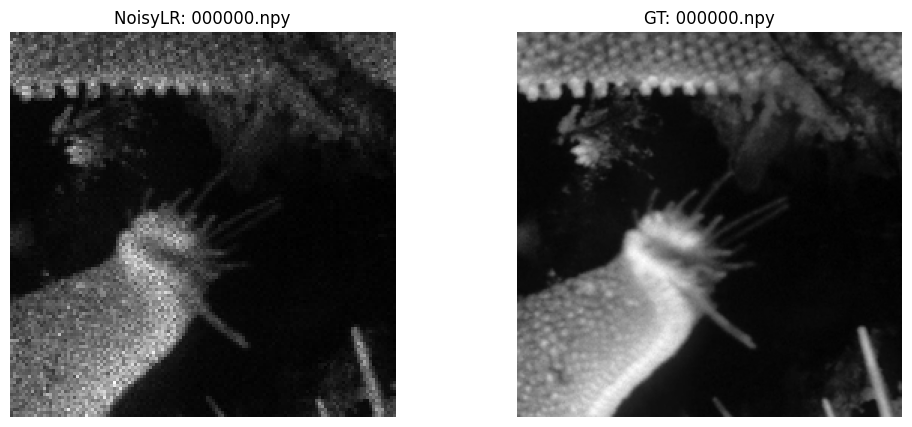

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(noisy, cmap="gray")
plt.title(f"NoisyLR: {sample_name}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gt, cmap="gray")
plt.title(f"GT: {sample_name}")
plt.axis("off")

plt.show()

In [20]:
print("NoisyLR")
print("Shape:", noisy.shape)

print("GT")
print("Shape:", gt.shape)

NoisyLR
Shape: (128, 128)
GT
Shape: (256, 256)


In [21]:
dataset_path = "/content/train"

In [22]:
import os
os.listdir("/content")

['.config', 'drive', 'train', '__MACOSX', 'train.zip', 'sample_data']

In [23]:
import os

print("Size:", os.path.getsize("/content/train.zip")/(1024*1024), "MB")

Size: 876.4211740493774 MB


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import pandas as pd
import zipfile

In [27]:
zip_path = "/content/drive/MyDrive/train.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/train.zip'

In [28]:
for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    print("Folders :", dirs)
    print("Files :", files[:5])
    print("-"*80)

In [29]:
import os

gt_path = "/content/train/GT"
lr_path = "/content/train/NoisyLR"

gt_files = sorted([
    f for f in os.listdir(gt_path)
    if f.endswith(".npy")
])

lr_files = sorted([
    f for f in os.listdir(lr_path)
    if f.endswith(".npy")
])

print("Ground Truth Images:", len(gt_files))
print("Noisy Images       :", len(lr_files))

Ground Truth Images: 3200
Noisy Images       : 3200


In [30]:
print("Pair Matching :", gt_files == lr_files)

Pair Matching : True


In [31]:
import numpy as np

gt = np.load(os.path.join(gt_path, gt_files[0]))
lr = np.load(os.path.join(lr_path, lr_files[0]))

print("GT Shape :", gt.shape)
print("LR Shape :", lr.shape)

print("GT dtype :", gt.dtype)
print("LR dtype :", lr.dtype)

print("GT Min :", gt.min(), "GT Max :", gt.max())
print("LR Min :", lr.min(), "LR Max :", lr.max())

GT Shape : (256, 256)
LR Shape : (128, 128)
GT dtype : float32
LR dtype : float32
GT Min : 0.0 GT Max : 1.0
LR Min : -0.0026427102 LR Max : 1.3257757


In [32]:
import numpy as np
import os

gt_shapes = []
lr_shapes = []

gt_min, gt_max = [], []
lr_min, lr_max = [], []

for file in gt_files:
    gt = np.load(os.path.join(gt_path, file))
    lr = np.load(os.path.join(lr_path, file))

    gt_shapes.append(gt.shape)
    lr_shapes.append(lr.shape)

    gt_min.append(gt.min())
    gt_max.append(gt.max())

    lr_min.append(lr.min())
    lr_max.append(lr.max())

print("Unique GT Shapes :", set(gt_shapes))
print("Unique LR Shapes :", set(lr_shapes))

print("GT Range :", min(gt_min), "to", max(gt_max))
print("LR Range :", min(lr_min), "to", max(lr_max))

Unique GT Shapes : {(256, 256)}
Unique LR Shapes : {(128, 128)}
GT Range : 0.0 to 1.0
LR Range : -0.27856305 to 2.158005


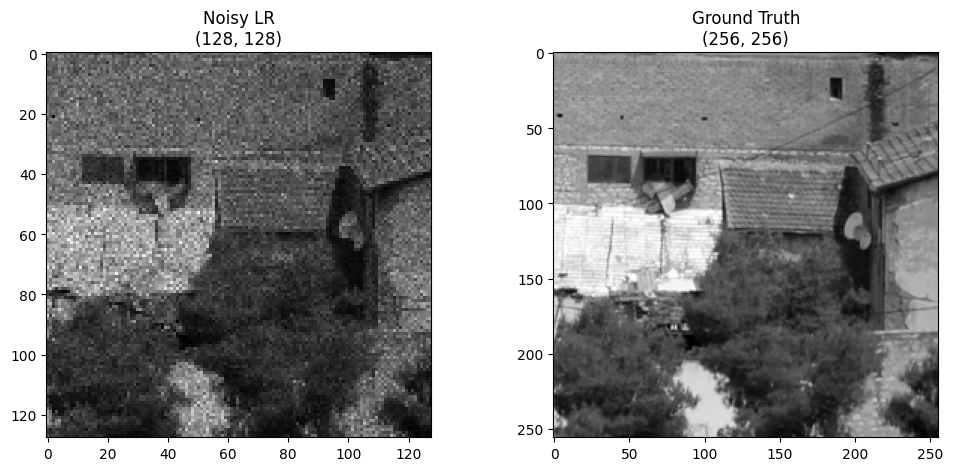

In [33]:
import matplotlib.pyplot as plt
import random

idx = random.randint(0, len(gt_files)-1)

gt = np.load(os.path.join(gt_path, gt_files[idx]))
lr = np.load(os.path.join(lr_path, lr_files[idx]))

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].imshow(lr, cmap='gray')
ax[0].set_title(f"Noisy LR\n{lr.shape}")

ax[1].imshow(gt, cmap='gray')
ax[1].set_title(f"Ground Truth\n{gt.shape}")

plt.show()